In [1]:
%%script echo 'This is the julia code used for simulation'

function glottis_ramp!(du, u, p, t)

    # unpack parameters
    γ = p[1]

    α = .035 + 0.2*t
    β = .03 + .1*t

    # unpack variables
    x, y = u

    # labial position dynamics (in normal form)
    du[1] = y
    du[2] = -α*γ^2 - β*γ^2*x - γ^2*x^3 - γ*x^2*y + γ^2*x^2 - γ*x*y

end

u0 = Float64[0., 0.] # initial conditions for x, y
tspan = (-.5, 2) # timespan to simulate 
prob = ODEProblem(glottis_ramp!, u0, tspan, (500));
T = (0, 1)
t = T[1]:(1/Fs):T[end]
x = Array(
    solve(
        prob, 
        Rosenbrock23(autodiff=false), 
        u0 = u0, p = (2000), 
        tspan = (-.5, T[end]), 
        saveat = t,
        force_dtmin = true
        )[1,:]
    );
alpha = .035 .+ 0.2 .* t
beta = .03 .+ .1 .* t

save("alpha.jld", "alpha", Array(alpha))
save("beta.jld", "beta", Array(beta))
save("t.jld", "t", Array(t))
save("x.jld", "x", x)

This is the julia code used for simulation


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import h5py
import os

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams.update({'font.size': 8})

# cm to inches conversion factor
CM = 1/2.54

def savefig(fname):
    if not os.path.exists('graphics'):
        os.mkdir('graphics')
    fpath = os.path.join('graphics', fname + '.png')
    plt.savefig(fpath, dpi = 500, bbox_inches = 'tight')

In [3]:
def load_jld(name):
    fname = '%s.jld'%name
    data = h5py.File(fname, 'r')
    return np.asarray(data[name])

t = load_jld('t')
x = load_jld('x')
pressure = load_jld('alpha')
tension = load_jld('beta')

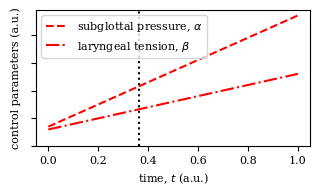

In [4]:
fig, ax = plt.subplots(figsize = (9*CM, 4.5*CM))
ax.plot(t, pressure, label = r'subglottal pressure, $\alpha$', color = 'red', linestyle = '--')
ax.plot(t, tension, label = r'laryngeal tension, $\beta$', color = 'red', linestyle = 'dashdot')
ax.axvline(.365, linestyle = 'dotted', color = 'black')#, label = 'bifurcation crossing')
ax.legend()
ax.set_ylim(0, None)
ax.set_xlabel('time, $t$ (a.u.)')
ax.set_ylabel('control parameters (a.u.)')
ax.set_yticklabels([])
savefig('trajectory')
plt.show()

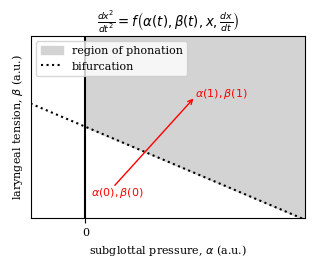

In [5]:
fig, ax = plt.subplots(figsize = (9*CM, 6*CM))

a = np.linspace(0, .2)
bif = .35 - 2.3*a
ax.fill_between(a, bif, .8*np.ones_like(a), color = 'lightgrey', label = 'region of phonation')
ax.set_xlim(-.05, .2)
ax.set_ylim(-.1, .8)
ax.axvline(0, color = 'black')
ax.plot(
    [-.05, .2], [.35 - 2.3*-.05, bif[-1]],
    color = 'black', linestyle = 'dotted', 
    label = 'bifurcation'
)
color = 'red'

# these aren't to scale, they just looks nice
alpha = (.025, .1)
beta = (.05, .5)

ax.annotate(
    r'',
    [alpha[-1], beta[-1]], 
    [alpha[0], beta[0]],
    arrowprops = dict(arrowstyle = '->', color = color),
    color = color,
)
ax.annotate(
    r'$\alpha(0), \beta(0)$',
    [alpha[-1], beta[-1]], 
    [alpha[0] - .02, beta[0] - .04],
    color = color
)
ax.annotate(
    r'$\alpha(1), \beta(1)$',
    [alpha[-1], beta[-1]], 
    color = color
)
ax.set_xticks([0])
ax.set_xticklabels([0])
ax.set_yticks([])
ax.set_xlabel(r'subglottal pressure, $\alpha$ (a.u.)')
ax.set_ylabel(r'laryngeal tension, $\beta$ (a.u.)')
ax.legend(loc = 'upper left')
ax.set_title(r'$\frac{dx^2}{dt^2} = f\left(\alpha(t), \beta(t), x, \frac{dx}{dt}\right)$')
savefig('dynamics')
plt.show()

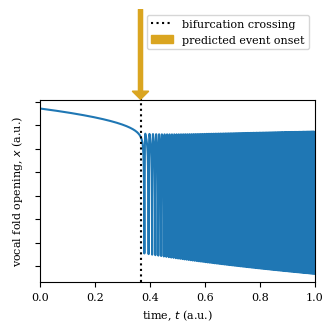

In [6]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize = (9*CM, 9*CM))
gs = gridspec.GridSpec(3, 1, hspace = 0)

ax = fig.add_subplot(gs[1:])
ax.plot(t, x)#, color = 'gray')
ax.set_xlim(0, 1)
ax.set_ylabel(r'vocal fold opening, $x$ (a.u.)')
ax.set_xlabel('time, $t$ (a.u.)')
ax.axvline(.365, linestyle = 'dotted', color = 'black', label = 'bifurcation crossing')
ax.set_yticklabels([])
#ax.legend()

ax = fig.add_subplot(gs[0])
ax.axvline(.365, linestyle = 'dotted', color = 'black', label = 'bifurcation crossing')
ax.arrow(
    .365, 1, 0, -.9, 
    color = 'goldenrod', 
    label = 'predicted event onset',
    width = .015,
    head_width = .06,
    alpha = 1,
    zorder = 10
)
#ax.set_xlabel('time, $t$ (a.u.)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()
ax.legend()
savefig('adduction')
plt.show()

In [7]:
from scipy.signal import butter, sosfilt, hilbert

# filter vocal fold position to get something that looks like audio 
fs = 1/(t[1] - t[0])
filt = butter(5, 20, 'highpass', fs = fs, output = 'sos')
x_filt = sosfilt(filt, x)
x_filt = np.roll(x_filt, int(.05*fs)) # delay auditory feedback
x_filt[t < .2] = 0 # fix edge artifact

# and then get envelope and onsets
import sys 
import os
cwd = os.getcwd()
pardir = os.path.abspath(os.path.join(cwd, os.pardir))
sys.path.append(pardir)
from util.envelope import compute_envelope
envelope, onsets = compute_envelope(x_filt, fs)

# smooth for prettiness 
filt = butter(1, 30, 'lowpass', fs = fs, output = 'sos')
envelope = sosfilt(filt, envelope)
onsets = sosfilt(filt, onsets)

# and rescale to match waveform
envelope /= (envelope.max()/x_filt.max())
onsets /= (onsets.max()/x_filt.max())

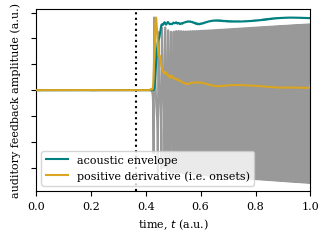

In [8]:
import sys 
import os
cwd = os.getcwd()
pardir = os.path.abspath(os.path.join(cwd, os.pardir))
sys.path.append(pardir)
from util.envelope import compute_envelope


fig, ax = plt.subplots(figsize = (9*CM, 6*CM))
ax.plot(t, x_filt, color = 'gray', alpha = .8)
ax.plot(t, envelope, color = 'teal', label = 'acoustic envelope')
ax.plot(t, onsets, color = 'goldenrod', label = 'positive derivative (i.e. onsets)', zorder = 10)
ax.set_xlim(0, 1)
ax.set_ylabel(r'auditory feedback amplitude (a.u.)')
ax.set_xlabel('time, $t$ (a.u.)')
ax.axvline(.365, linestyle = 'dotted', color = 'black')
ax.set_yticklabels([])
ax.legend()
savefig('acoustics')
plt.show()